In [1]:
from collections import Counter
import hashlib
from IPython import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import statsmodels.stats.multitest as multitests
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test
from statsmodels.stats.multitest import multipletests

# Load data

In [50]:
df_incident = pd.read_csv(r'C:\Users\eguen\Documents\Githubs-Redlat\Repo-Gap\Brainlat\Data\incidence_db.csv', index_col=0)
results_GB_orig = pd.read_parquet(r'C:\Users\eguen\Documents\Githubs-Redlat\Repo-Gap\Brainlat\Results\all-vars_all-subjects.parquet')

In [51]:
results_GB_orig.columns

Index(['centreid', 'date', 'Age', 'anydem', 'dsmcase', 'cogcase', 'mci',
       'Countries', 'Angina', 'Arthritis', 'Assets', 'Ataxia',
       'Audition_problems', 'Back_diseases', 'Bradykinesia', 'Breath_problems',
       'Breathlessness', 'CERADrecall', 'Cogscore', 'DSMIV', 'Disability',
       'Education', 'Emotional_Disability', 'Euro-D', 'Exercise_increase',
       'Faints', 'Family_dementia_any', 'Heart_Disease_1Y_0N',
       'Hypertension_1Y_0N', 'ICD10', 'Medications_1Y_0N',
       'NPI severity score', 'Pain', 'Paralysis', 'Physical_activities', 'SRQ',
       'Sex_1F_2M', 'Skin_disorder', 'Stomach_problems', 'Stroke_1Y_0N',
       'Vision_problems', 'Walk_1Y_0N', 'orthostatic_drop', 'pulse_pressure',
       'y_labels', 'y_pred', 'GAP', 'GAP_corrected', 'y_pred_corrected',
       'uid'],
      dtype='object')

## Matching

In [52]:
# (optional) check the proportion of valid UIDs
print(df_incident["uid"].notna().mean(), results_GB_orig["uid"].notna().mean())

# matching / merging
matched = df_incident.merge(results_GB_orig, on="uid", how="inner", suffixes=("_inc", "_gb"))

0.7982899339292654 1.0


# Define death and end date, and event


## I dont consider alive participant without f_date anda death_date

### All subjects

In [53]:
matched = df_incident.merge(results_GB_orig, on="uid", how="inner", suffixes=("_inc", "_gb"))

matched["date"] = pd.to_datetime(matched["date"], errors="coerce")
matched["death_date"] = pd.to_datetime(matched["death_date"], errors="coerce")
matched["f_date"] = pd.to_datetime(matched["f_date"], errors="coerce")


matched["event"] = matched["death_date"].notna().astype(int)

# End date:
# - if died -> death_date
# - if not died -> f_date (last evaluation)
matched["end_date"] = matched["death_date"].fillna(matched["f_date"])

# (Optional, in case any end_date is empty)
matched["end_date"] = matched["end_date"].fillna(matched["date"].max())

# Time in years
matched["time_years"] = (matched["end_date"] - matched["date"]).dt.days / 365.25

# (Optional) Mark invalid times as NaN
matched.loc[matched["time_years"] < 0, "time_years"] = np.nan
matched.loc[matched["time_years"] > 5.5, "time_years"] = np.nan

<Axes: >

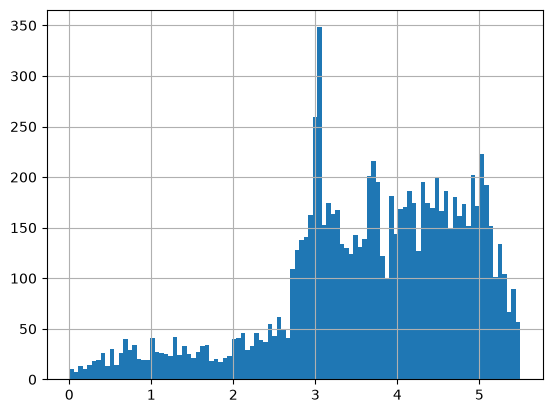

In [54]:
matched["time_years"].hist(bins = 100)

### Finding the best threshold for disability

In [55]:
df_base = matched[["Disability", "time_years", "event"]].dropna().copy()

thresholds = np.linspace(df_base["Disability"].min(),
                         df_base["Disability"].max(), 100)

best_p = 1
best_t = None

for t in thresholds:
    df_base["Disability_bin"] = np.where(df_base["Disability"] <= t, 0, 1)

    group1 = df_base[df_base["Disability_bin"] == 0]
    group2 = df_base[df_base["Disability_bin"] == 1]

    if len(group1) > 10 and len(group2) > 10:
        result = logrank_test(
            group1["time_years"],
            group2["time_years"],
            event_observed_A=group1["event"],
            event_observed_B=group2["event"]
        )

        if result.p_value < best_p:
            best_p = result.p_value
            best_t = t

print("Best threshold:", best_t)
print("Best p-value:", best_p)

# Recreate the binary variable using the best threshold
df_base["Disability_bin"] = np.where(df_base["Disability"] <= best_t, 0, 1)

# Cox model
cph = CoxPHFitter()
cph.fit(df_base[["time_years", "event", "Disability_bin"]],
        duration_col="time_years",
        event_col="event")

#cph.print_summary()

# Extract HR and CI
hr = np.exp(cph.params_["Disability_bin"])
ci_low = np.exp(cph.confidence_intervals_.loc["Disability_bin"].iloc[0])
ci_high = np.exp(cph.confidence_intervals_.loc["Disability_bin"].iloc[1])
p_cox = cph.summary.loc["Disability_bin", "p"]

print(f"HR for best threshold: {hr:.3f}")
print(f"95% CI: ({ci_low:.3f}, {ci_high:.3f})")
print(f"Cox p-value: {p_cox:.6f}")

Best threshold: 34.343434343434346
Best p-value: 3.0781213114850085e-143
HR for best threshold: 4.055
95% CI: (3.609, 4.557)
Cox p-value: 0.000000


In [56]:
best_t

np.float64(34.343434343434346)

In [57]:
matched['ICD10'].value_counts()

ICD10
0    9509
1     632
Name: count, dtype: int64

In [58]:
covars_bin = ["GAP_min0_max1_no_outliers", 'Hypertension', 'Heart_Disease', 'Angina', 'ICD10_r', 'DSMIV', 'Euro-D_min0_max1_no_outliers', 'Disability_min0_max1_no_outliers', 'composite_score_min0_max1_no_outliers', 'composite_score_extended_min0_max1_no_outliers']

covars_fixeds = ['Age', 'Male', 'Education']

In [59]:
matched[[
  'Hypertension_1Y_0N',
  'Heart_Disease_1Y_0N',
  'Angina',
  'ICD10',
  'DSMIV',
  'Disability',
  'Euro-D'
]].isna().sum()

Hypertension_1Y_0N     0
Heart_Disease_1Y_0N    0
Angina                 0
ICD10                  0
DSMIV                  0
Disability             0
Euro-D                 0
dtype: int64

### Better and cleaner code

In [ ]:
# Copy base dataframe
df_base = matched.copy()
# Use the threshold, not the HR
df_base["Disability_bin"] = np.where(
  df_base["Disability"].isna(),
  np.nan,
  np.where(df_base["Disability"] <= best_t, 0, 1)
)

# Recode Euro-D to 0, 1, 2
df_base["Euro-D_rescaled"] = np.select(
  [
    df_base["Euro-D"] == 0,
    (df_base["Euro-D"] > 0) & (df_base["Euro-D"] < 1),
    df_base["Euro-D"] >= 1
  ],
  [0, 1, 2],
  default=np.nan
)

# -------------------------
# Composite with binary disability
# Max possible score = 6 binary vars + Euro-D max 2 = 8
# -------------------------
cols_binary = [
  'Hypertension_1Y_0N',
  'Heart_Disease_1Y_0N',
  'Angina',
  'ICD10',
  'DSMIV',
  'Disability_bin',
  'Euro-D_rescaled'
]

df_base["composite_score"] = df_base[cols_binary].sum(axis=1) / (len(cols_binary)+1) # Plus one for the extra severity value of Euro-D

q1_dis = df_base["composite_score"].quantile(0.25)
q3_dis = df_base["composite_score"].quantile(0.75)
dis_iqr = q3_dis - q1_dis
dis_lower = q1_dis - 1.5 * dis_iqr
dis_upper = q3_dis + 1.5 * dis_iqr

df_base["composite_score_no_outliers"] = df_base["composite_score"].where(
  (df_base["composite_score"] >= dis_lower) &
  (df_base["composite_score"] <= dis_upper),
  np.nan
)

scaler_dis = MinMaxScaler(feature_range=(0, 1))
df_base["composite_score_min0_max1_no_outliers"] = scaler_dis.fit_transform(
  df_base[["composite_score_no_outliers"]]
)

# -------------------------
# Composite with continuous disability rescaled to 0-1
# Max possible score = 5 binary vars + Disability_r max 1 + Euro-D max 2 = 8
# -------------------------
df_base["Disability_r"] = df_base["Disability"] / 10

cols = [
  'Hypertension_1Y_0N',
  'Heart_Disease_1Y_0N',
  'Angina',
  'ICD10',
  'DSMIV',
  'Disability_r',
  'Euro-D_rescaled'
]

df_base["composite_score_extended"] = df_base[cols].sum(axis=1) / (len(cols_binary)+1 + 9) # Plus one for the extra severity value of Euro-D and +9 for the 9 extra disability values between 0 and 10

q1_dis = df_base["composite_score_extended"].quantile(0.25)
q3_dis = df_base["composite_score_extended"].quantile(0.75)
dis_iqr = q3_dis - q1_dis
dis_lower = q1_dis - 1.5 * dis_iqr
dis_upper = q3_dis + 1.5 * dis_iqr

df_base["composite_score_extended_no_outliers"] = df_base["composite_score_extended"].where(
  (df_base["composite_score_extended"] >= dis_lower) &
  (df_base["composite_score_extended"] <= dis_upper),
  np.nan
)

scaler_dis = MinMaxScaler(feature_range=(0, 1))
df_base["composite_score_extended_min0_max1_no_outliers"] = scaler_dis.fit_transform(
  df_base[["composite_score_extended_no_outliers"]]
)

# Create binary covariates
df_base["Male"] = (df_base["Sex_1F_2M"] == 2).astype(int)
df_base["ICD10_r"] = (df_base["ICD10"] == 1).astype(int)
df_base["Hypertension"] = (df_base["Hypertension_1Y_0N"] == 1).astype(int)
df_base["Heart_Disease"] = (df_base["Heart_Disease_1Y_0N"] == 1).astype(int)
df_base["Angina"] = (df_base["Angina"] == 1).astype(int)
df_base["DSMIV"] = (df_base["DSMIV"] == 1).astype(int)

# Z-scores
gap_std = df_base["GAP_corrected"].std()
dis_std = df_base["Disability"].std()

df_base["GAP_z"] = (
  (df_base["GAP_corrected"] - df_base["GAP_corrected"].mean()) / gap_std
  if gap_std != 0 else np.nan
)

df_base["Disability_z"] = (
  (df_base["Disability"] - df_base["Disability"].mean()) / dis_std
  if dis_std != 0 else np.nan
)

# Min-max scaling for full variables
scaler_gap = MinMaxScaler(feature_range=(0, 1))
df_base["GAP_min0_max1"] = scaler_gap.fit_transform(df_base[["GAP_corrected"]])

scaler_dis = MinMaxScaler(feature_range=(0, 1))
df_base["Disability_min0_max1"] = scaler_dis.fit_transform(df_base[["Disability"]])

scaler_dis = MinMaxScaler(feature_range=(0, 1))
df_base["Euro-D_min0_max1_no_outliers"] = scaler_dis.fit_transform(df_base[["Euro-D"]])

# Percentile-based scaling for GAP
p5_gap = df_base["GAP_corrected"].quantile(0.05)
p95_gap = df_base["GAP_corrected"].quantile(0.95)
gap_den = p95_gap - p5_gap

delta = gap_den / gap_std if gap_std != 0 else np.nan

if gap_den != 0:
  df_base["GAP_percentiles"] = (df_base["GAP_corrected"] - p5_gap) / gap_den
else:
  df_base["GAP_percentiles"] = np.nan

# Winsorized GAP scaled to [0, 1]
gap_clipped = np.clip(df_base["GAP_corrected"], p5_gap, p95_gap)
if gap_den != 0:
  df_base["GAP_winsor"] = (gap_clipped - p5_gap) / gap_den
else:
  df_base["GAP_winsor"] = np.nan

# Percentile-based scaling for Disability
p5_dis = df_base["Disability"].quantile(0.05)
p95_dis = df_base["Disability"].quantile(0.95)
dis_den = p95_dis - p5_dis

if dis_den != 0:
  df_base["Disability_percentiles"] = (df_base["Disability"] - p5_dis) / dis_den
else:
  df_base["Disability_percentiles"] = np.nan

# IQR-based outlier handling for GAP
p25_gap = df_base["GAP_corrected"].quantile(0.25)
p75_gap = df_base["GAP_corrected"].quantile(0.75)
gap_iqr = p75_gap - p25_gap
gap_lower = p25_gap - 1.5 * gap_iqr
gap_upper = p75_gap + 1.5 * gap_iqr

df_base["GAP_no_outliers"] = df_base["GAP_corrected"].where(
  (df_base["GAP_corrected"] >= gap_lower) &
  (df_base["GAP_corrected"] <= gap_upper),
  np.nan
)

gap_mask = df_base["GAP_no_outliers"].notna()
if gap_mask.sum() > 0:
  scaler_gap_no_out = MinMaxScaler(feature_range=(0, 1))
  df_base.loc[gap_mask, "GAP_min0_max1_no_outliers"] = scaler_gap_no_out.fit_transform(
    df_base.loc[gap_mask, ["GAP_no_outliers"]]
  )
else:
  df_base["GAP_min0_max1_no_outliers"] = np.nan

# IQR-based outlier handling for Disability
q1_dis = df_base["Disability"].quantile(0.25)
q3_dis = df_base["Disability"].quantile(0.75)
dis_iqr = q3_dis - q1_dis
dis_lower = q1_dis - 1.5 * dis_iqr
dis_upper = q3_dis + 1.5 * dis_iqr

df_base["Disability_no_outliers"] = df_base["Disability"].where(
  (df_base["Disability"] >= dis_lower) &
  (df_base["Disability"] <= dis_upper),
  np.nan
)

dis_mask = df_base["Disability_no_outliers"].notna()
if dis_mask.sum() > 0:
  scaler_dis_no_out = MinMaxScaler(feature_range=(0, 1))
  df_base.loc[dis_mask, "Disability_min0_max1_no_outliers"] = scaler_dis_no_out.fit_transform(
    df_base.loc[dis_mask, ["Disability_no_outliers"]]
  )
else:
  df_base["Disability_min0_max1_no_outliers"] = np.nan

# Check that all requested exposures exist
missing_covars = [x for x in covars_bin if x not in df_base.columns]
if len(missing_covars) > 0:
  raise ValueError(f"The following variables are not in df_base: {missing_covars}")

# Parameters
n_iterations = 1000
random_state = 42

# Bootstrap Cox models
df_binary_table = {}

for expo in covars_bin:
  print(expo)
  results = []
  rng = np.random.default_rng(random_state)

  for i in range(n_iterations):
    # Bootstrap sample with replacement
    sample_idx = rng.choice(df_base.index, size=len(df_base), replace=True)
    df_boot = df_base.loc[sample_idx].reset_index(drop=True).copy()

    # Keep only required columns and drop missing values
    df_boot = df_boot[["time_years", "event", expo, "Age", "Male", "Education"]].dropna().copy()
    df_boot.reset_index(drop=True, inplace=True)

    # Skip iterations with no usable rows
    if len(df_boot) == 0:
      results.append({
        "iteration": i + 1,
        "n": 0,
        "HR_" + expo: np.nan,
        "CI_95_lower": np.nan,
        "CI_95_upper": np.nan,
        "p_value": np.nan
      })
      continue

    # Optional: skip if exposure has no variability
    if df_boot[expo].nunique() < 2:
      results.append({
        "iteration": i + 1,
        "n": len(df_boot),
        "HR_" + expo: np.nan,
        "CI_95_lower": np.nan,
        "CI_95_upper": np.nan,
        "p_value": np.nan
      })
      continue

    try:
      cph = CoxPHFitter()
      cph.fit(
        df_boot,
        duration_col="time_years",
        event_col="event"
      )

      row = cph.summary.loc[expo]

      # Convert HR for GAP_z from 1 SD to p5-p95 range
      if expo == "GAP_z" and pd.notna(delta):
        hr = row["exp(coef)"] ** delta
        ci_low = row["exp(coef) lower 95%"] ** delta
        ci_up = row["exp(coef) upper 95%"] ** delta
      else:
        hr = row["exp(coef)"]
        ci_low = row["exp(coef) lower 95%"]
        ci_up = row["exp(coef) upper 95%"]

      results.append({
        "iteration": i + 1,
        "n": len(df_boot),
        "HR_" + expo: hr,
        "CI_95_lower": ci_low,
        "CI_95_upper": ci_up,
        "p_value": row["p"]
      })

    except Exception as e:
      print(f"Error in {expo}, iteration {i + 1}: {e}")
      results.append({
        "iteration": i + 1,
        "n": len(df_boot),
        "HR_" + expo: np.nan,
        "CI_95_lower": np.nan,
        "CI_95_upper": np.nan,
        "p_value": np.nan
      })

  df_binary_table[expo] = pd.DataFrame(results)

df_binary_table;

GAP_min0_max1_no_outliers
Hypertension
Heart_Disease
Angina
ICD10_r
DSMIV
Euro-D_min0_max1_no_outliers
Disability_min0_max1_no_outliers
composite_score_min0_max1_no_outliers
composite_score_extended_min0_max1_no_outliers


In [36]:
df_binary_table.keys()

dict_keys(['GAP_min0_max1_no_outliers', 'Hypertension', 'Heart_Disease', 'Angina', 'ICD10_r', 'DSMIV', 'Euro-D_min0_max1_no_outliers', 'Disability_min0_max1_no_outliers', 'composite_score_min0_max1_no_outliers', 'composite_score_extended_min0_max1_no_outliers'])

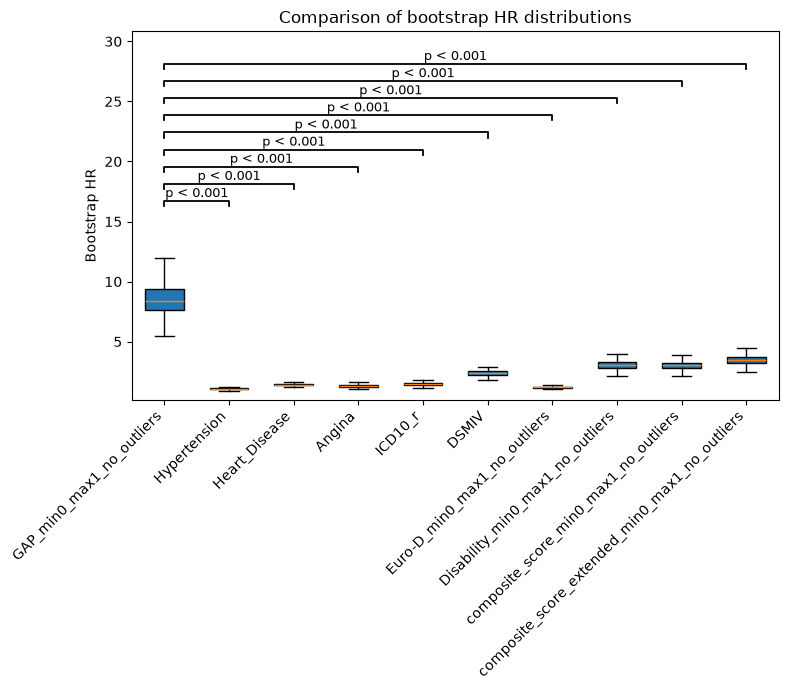

In [42]:
# Reference variable
ref_var = "GAP_min0_max1_no_outliers"

# Variables to compare
compare_vars = [
  "Hypertension",
  "Heart_Disease",
  "Angina",
  "ICD10_r",  # note: in your code it was ICD10_r, not ICD10
  "DSMIV",
  "Euro-D_min0_max1_no_outliers",
  "Disability_min0_max1_no_outliers",
  'composite_score_min0_max1_no_outliers',
  'composite_score_extended_min0_max1_no_outliers'
]

# -----------------------------
# Permutation test
# -----------------------------
def permutation_test(x, y, n_perm=5000, random_state=42):
  rng = np.random.default_rng(random_state)
  x = np.asarray(x)
  y = np.asarray(y)

  x = x[~np.isnan(x)]
  y = y[~np.isnan(y)]

  observed = np.abs(np.mean(x) - np.mean(y))
  combined = np.concatenate([x, y])

  count = 0
  for _ in range(n_perm):
    perm = rng.permutation(combined)
    x_perm = perm[:len(x)]
    y_perm = perm[len(x):]
    stat = np.abs(np.mean(x_perm) - np.mean(y_perm))
    if stat >= observed:
      count += 1

  p_value = (count + 1) / (n_perm + 1)
  return p_value

# -----------------------------
# Extract HRs from df_binary_table
# -----------------------------
plot_data = []
pvals = []

# Reference HR
ref_col = "HR_" + ref_var
ref_values = df_binary_table[ref_var][ref_col].dropna().values

plot_data.append(pd.DataFrame({
  "Variable": ref_var,
  "HR": ref_values
}))

for var in compare_vars:
  hr_col = "HR_" + var
  
  if var not in df_binary_table:
    print(f"Variable not found in df_binary_table: {var}")
    continue
  
  vals = df_binary_table[var][hr_col].dropna().values

  plot_data.append(pd.DataFrame({
    "Variable": var,
    "HR": vals
  }))

  pval = permutation_test(ref_values, vals, n_perm=10000, random_state=42)
  pvals.append((var, pval))




plot_df = pd.concat(plot_data, ignore_index=True)

# Order
order = [ref_var] + [v for v in compare_vars if v in plot_df["Variable"].unique()]

# -----------------------------
# Boxplot
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 7))

data_to_plot = [
  plot_df.loc[plot_df["Variable"] == var, "HR"].dropna().values
  for var in order
]

bp = ax.boxplot(
  data_to_plot,
  positions=np.arange(len(order)),
  widths=0.6,
  patch_artist=True,
  showfliers=False
)

# Labels
ax.set_xticks(np.arange(len(order)))
ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_ylabel("Bootstrap HR")
ax.set_title("Comparison of bootstrap HR distributions")

# -----------------------------
# Lines and p-values
# -----------------------------
y_max = np.nanmax(plot_df["HR"])
y_min = np.nanmin(plot_df["HR"])
y_range = y_max - y_min

if y_range == 0:
  y_range = 1

base_height = y_max + 0.08 * y_range
step = 0.10 * y_range

for j, (var, pval) in enumerate(pvals, start=1):
  x1 = 0
  x2 = order.index(var)
  y = base_height + (j - 1) * step

  # comparison line
  ax.plot([x1, x1, x2, x2], [y, y + 0.03*y_range, y + 0.03*y_range, y],
      lw=1.3, c="black")

  pval = pval*len(compare_vars)
  # p-value text
  if pval < 0.001:
    label = "p < 0.001"
  else:
    label = f"p = {pval:.4f}"

  ax.text((x1 + x2) / 2, y + 0.035*y_range, label,
      ha="center", va="bottom", fontsize=9)

# Adjust upper limit so lines aren't cut
ax.set_ylim(y_min - 0.05*y_range, base_height + len(pvals)*step + 0.12*y_range)

plt.tight_layout()

plt.savefig("Figures/HR-comparison.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

In [ ]:
pvals

In [ ]:
multipletests(pvals, method='bonferroni')[1] 

In [ ]:
df_base["GAP_corrected"].std()

In [ ]:
for i in covars_bin:
  print(i)
  display(df_binary_table[i].head(1))

GAP_z


,iteration,n,HR_GAP_z,CI_95_lower,CI_95_upper,p_value
0,1,9555,3.612822,3.101859,4.207955,3.115465e-61


GAP_min0_max1


,iteration,n,HR_GAP_min0_max1,CI_95_lower,CI_95_upper,p_value
0,1,9555,22.054711,15.275943,31.841586,3.115465e-61


GAP_percentiles


...

,iteration,n,HR_Disability_percentiles,CI_95_lower,CI_95_upper,p_value
0,1,9555,3.271269,2.901498,3.688164,1.509315e-83


Disability_min0_max1_no_outliers


,iteration,n,HR_Disability_min0_max1_no_outliers,CI_95_lower,CI_95_upper,p_value
0,1,8904,2.944294,2.400016,3.612003,3.969787e-25


Disability_min0_max1


,iteration,n,HR_Disability_min0_max1,CI_95_lower,CI_95_upper,p_value
0,1,9555,8.442852,6.803306,10.477517,1.509315e-83


In [ ]:
row["exp(coef) lower 95%"]

2.8561173294667266


In [ ]:
df_binary_table['GAP_z'].head(1)

,iteration,n,HR_GAP_z,CI_95_lower,CI_95_upper,p_value
0,1,9527,1.633753,1.53965,1.733607,3.782021e-59


In [ ]:
np.exp(0.021330)

1.021559110526227

In [ ]:
df_binary_table['GAP_z']

,iteration,n,HR_GAP_z,CI_95_lower,CI_95_upper,p_value
0,1,9527,1.359057,1.298148,1.424887,3.747084e-74
1,2,9527,1.359057,1.298148,1.424887,3.747084e-74
2,3,9527,1.359057,1.298148,1.424887,3.747084e-74
3,4,9527,1.359057,1.298148,1.424887,3.747084e-74
4,5,9527,1.359057,1.298148,1.424887,3.747084e-74
5,6,9527,1.359057,1.298148,1.424887,3.747084e-74
6,7,9527,1.359057,1.298148,1.424887,3.747084e-74
7,8,9527,1.359057,1.298148,1.424887,3.747084e-74
8,9,9527,1.359057,1.298148,1.424887,3.747084e-74
9,10,9527,1.359057,1.298148,1.424887,3.747084e-74


In [ ]:
expo

'Disability'

In [ ]:
df_binary_table[expo]

,iteration,n,n_gap_0,n_gap_1,HR_Disability,CI_95_lower,CI_95_upper,p_value
0,1,9527,3672,0,1.021559,1.019321,1.023802,5.097394e-81
1,2,9527,3672,0,1.021559,1.019321,1.023802,5.097394e-81
2,3,9527,3672,0,1.021559,1.019321,1.023802,5.097394e-81
3,4,9527,3672,0,1.021559,1.019321,1.023802,5.097394e-81
4,5,9527,3672,0,1.021559,1.019321,1.023802,5.097394e-81
5,6,9527,3672,0,1.021559,1.019321,1.023802,5.097394e-81
6,7,9527,3672,0,1.021559,1.019321,1.023802,5.097394e-81
7,8,9527,3672,0,1.021559,1.019321,1.023802,5.097394e-81
8,9,9527,3672,0,1.021559,1.019321,1.023802,5.097394e-81
9,10,9527,3672,0,1.021559,1.019321,1.023802,5.097394e-81


In [ ]:
df_binary_table['GAP_bin']

,iteration,n,n_gap_0,n_gap_1,HR_GAP_bin,CI_95_lower,CI_95_upper,p_value
0,1,9527,1,0,27.327075,18.789983,39.742934,3.992750e-67
1,2,9527,4,0,26.157243,18.241333,37.508296,1.738069e-70
2,3,9527,2,0,24.673391,16.780162,36.279521,1.029738e-59
3,4,9527,0,0,21.804629,15.029043,31.634871,2.955147e-59
4,5,9527,0,4,26.040487,17.959435,37.757699,2.864543e-66
5,6,9527,2,1,19.266363,13.235395,28.045462,8.424326e-54
6,7,9527,0,0,28.908315,19.758413,42.295437,2.972066e-67
7,8,9527,0,0,21.156849,14.503017,30.863389,1.617664e-56
8,9,9527,1,1,23.157091,16.035017,33.442487,4.996853e-63
9,10,9527,1,3,21.465590,14.817459,31.096531,3.929325e-59


In [ ]:
df_base = matched.copy()

matched["GAP_z"] = (matched["GAP_corrected"] - matched["GAP_corrected"].mean()) / matched["GAP_corrected"].std()

thresholds = np.linspace(df_base["GAP_z"].min(),
             df_base["GAP_z"].max(), 100)

best_p = 1
best_t = None

for t in thresholds:
  df_base["GAP_bin"] = np.where(df_base["GAP_z"] <= t, 0, 1)

  group1 = df_base[df_base["GAP_bin"] == 0]
  group2 = df_base[df_base["GAP_bin"] == 1]

  if len(group1) > 10 and len(group2) > 10:
    result = logrank_test(group1["time_years"], group2["time_years"],
               event_observed_A=group1["event"],
               event_observed_B=group2["event"])
    
    if result.p_value < best_p:
      best_p = result.p_value
      best_t = t

print("Best threshold:", best_t)
print("Best p-value:", best_p)

Best threshold: 1.1858193449500152
Best p-value: 3.5148965472347566e-93
